In [1]:
import pandas as pd
import numpy as np


In [2]:
# Load dataset
df = pd.read_csv("dataset.csv")

print("Dataset shape:",df.shape)
df.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52.0,1.0,0.0,125.0,212.0,0.0,1.0,168.0,0.0,1.0,2.0,2.0,3.0,0.0
1,53.0,1.0,0.0,140.0,203.0,1.0,0.0,155.0,1.0,3.1,0.0,0.0,3.0,0.0
2,70.0,1.0,0.0,145.0,NaN,0.0,1.0,125.0,1.0,2.6,0.0,0.0,3.0,0.0
3,61.0,1.0,0.0,148.0,203.0,0.0,1.0,161.0,0.0,0.0,2.0,1.0,3.0,0.0
4,62.0,0.0,0.0,138.0,294.0,1.0,1.0,106.0,0.0,1.9,1.0,3.0,2.0,0.0


In [5]:
#Check missing values
print("Missing values in dataset:")
print(df.isnull().sum())

Missing values in dataset:
age         51
sex         51
cp          51
trestbps    48
chol        50
fbs         51
restecg     51
thalach     51
exang       51
oldpeak     51
slope       51
ca          51
thal        47
target      51
dtype: int64


In [17]:
# ============================================
# STEP 3: CLEAN DATASET
# ============================================

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')


# Fill missing numerical column values with median
num_cols = ["age","trestbps","chol","thalach","oldpeak"]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical column values with mode

cat_cols = ["sex","cp","fbs","restecg","exang","slope","ca","thal"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

#dropping missing target values

missing_target = df['target'].isnull().sum()
print(f"Missing target values: {missing_target}")

df = df.dropna(subset=['target'])

# Verify no missing values remain
print("Missing values in Dataset after cleaning:")
print(df.isnull().sum().sum(), "missing values")


Missing target values: 51
Missing values in Dataset after cleaning:
0 missing values


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 974 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       974 non-null    float64
 1   sex       974 non-null    float64
 2   cp        974 non-null    float64
 3   trestbps  974 non-null    float64
 4   chol      974 non-null    float64
 5   fbs       974 non-null    float64
 6   restecg   974 non-null    float64
 7   thalach   974 non-null    float64
 8   exang     974 non-null    float64
 9   oldpeak   974 non-null    float64
 10  slope     974 non-null    float64
 11  ca        974 non-null    float64
 12  thal      974 non-null    float64
 13  target    974 non-null    float64
dtypes: float64(14)
memory usage: 114.1 KB


In [27]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000,974.000000
mean,54.571869,0.714579,0.905544,131.745380,247.612423,0.141684,0.554415,149.060062,0.317248,1.031211,1.368583,0.713552,2.300821,0.514374
std,8.792484,0.451847,1.025527,16.587705,48.163070,0.348905,0.525424,22.242845,0.465644,1.090947,0.603755,1.009249,0.605609,0.500050
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,85.625000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,214.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,0.000000,130.000000,243.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.000000,0.000000,1.000000,165.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,170.000000,366.500000,1.000000,2.000000,202.000000,1.000000,4.000000,2.000000,4.000000,3.000000,1.000000


In [23]:
# ============================================
# STEP 4: HANDLING THE OUTLIERS
# ============================================

def remove_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] > upper, upper,
              np.where(df[col] < lower, lower, df[col]))

for col in num_cols:
    remove_outliers(col)


In [29]:
# fix target variable

df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [33]:
# ============================================
# STEP 5: SAVE CLEANED DATASET
# ============================================
df.to_csv('dataset_cleaned.csv', index=False)


print("Cleaned files saved!")
print("Dataset shape:", df.shape)


Cleaned files saved!
Dataset shape: (974, 14)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

#=============================================
#Step 5: Exploratory data analysis
#=============================================
#basic statistics
print("Dataset Statistics:")
df1.describe()

Dataset Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.460488,0.715122,0.945366,133.768780,253.278049,0.141463,0.555122,149.066341,0.319024,1.054244,1.368780,0.710244,2.297561,0.538537
std,8.861381,0.451577,1.002409,23.480798,69.368818,0.348669,0.523972,22.499077,0.466326,1.145799,0.604832,1.007270,0.604543,0.498756
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,214.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,243.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.000000,0.000000,1.000000,165.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,250.000000,600.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


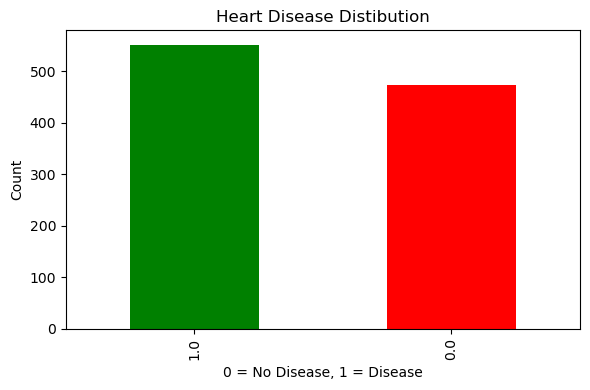

In [8]:
#Target variable distribution
plt.figure(figsize=(6,4))
df1['target'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Heart Disease Distibution')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

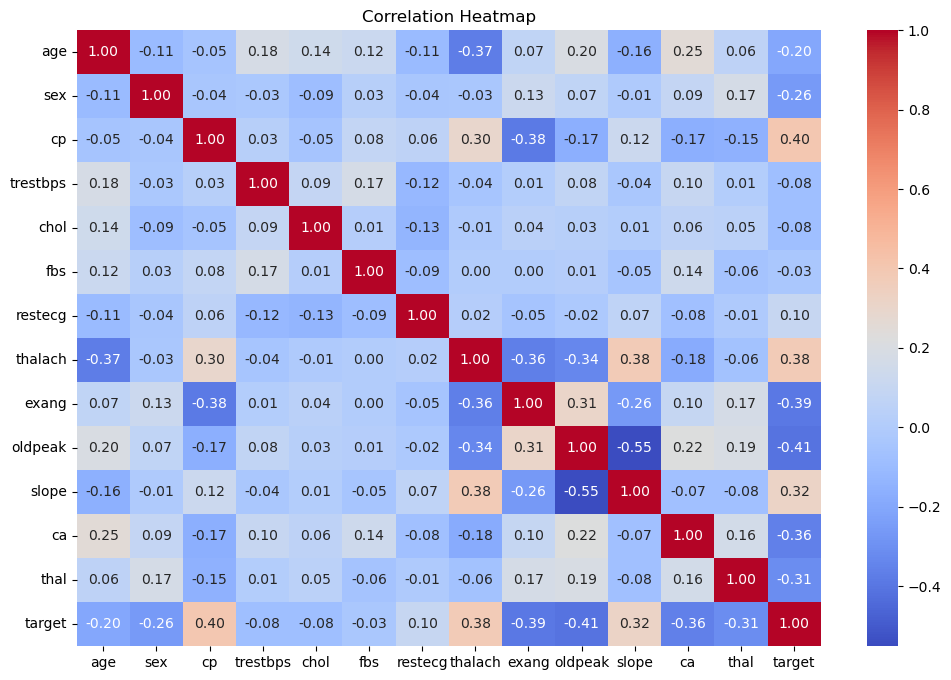

In [9]:
# Correlation heatmap
import seaborn as snsplt
plt.figure(figsize=(12,8))
sns.heatmap(df1.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df1.drop('target', axis=1)
y = df1['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred)*100, "%")

✅ Accuracy: 92.6829268292683 %
